# Self-Attention과 Transformer — 시계열 데이터로 이해하기

## 목차

| 회차 | 파트 | 주제 | 핵심 |
|------|------|------|------|
| 1 | Part 1 | RNN/LSTM의 정보 병목 | 마지막 hidden 하나로 긴 시계열을 압축하는 한계 |
| 2 | Part 2 | Attention의 직관 | Query-Key-Value와 가중합 |
| 3 | Part 3 | Self-Attention | 같은 시계열 내부 시점들이 서로를 참조 |
| 4 | Part 4 | Positional Encoding | Attention에 시간 순서 정보 추가 |
| 5 | Part 5 | Multi-Head Attention | 여러 관점으로 단기·주기·이벤트 패턴 관찰 |
| 6 | Part 6 | Transformer Encoder | 표준 Encoder 블록을 시계열 입력에 적용 |
| 7 | Part 7 | 종합 실습 | 합성 전력 사용량 시계열 다음 값 예측 |

> 지난 시간에는 RNN/LSTM으로 시계열을 다루며, LSTM이 긴 정보를 더 잘 보존한다는 점을 배웠습니다. 이번 시간에는 **필요한 시점을 직접 다시 보는 Self-Attention**에서 출발해, **일반 Transformer Encoder를 시계열 예측에 적용하는 방법**까지 연결하겠습니다.


In [2]:
# [시나리오] 이번 교안 전체에서 공통으로 사용할 라이브러리와 실행 환경을 준비합니다.
# 입력: numpy, pandas, matplotlib, PyTorch
# 출력: 모든 실습 셀이 같은 설정으로 실행됩니다.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(1)

set_seed(42)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "AppleGothic"

print("공통 설정이 완료되었습니다.")
print(f"PyTorch 버전: {torch.__version__}")


ModuleNotFoundError: No module named 'pandas'

---

## Part 1. RNN/LSTM의 정보 병목

RNN과 LSTM은 시점을 순서대로 읽으면서 은닉 상태를 갱신합니다. many-to-one 예측에서는 보통 마지막 은닉 상태 하나를 꺼내서 다음 값을 예측합니다.

이 방식은 자연스럽지만, 긴 시계열에서는 **초기 정보가 마지막 hidden에 도착하기 전까지 여러 번 압축**됩니다. LSTM은 이 문제를 완화하지만, 필요한 모든 시점을 마지막 벡터 하나에 담아야 한다는 구조적 부담은 남습니다.

<img src="images/04_transformer_timeseries/rnn_bottleneck.png" width="900">

> Attention의 핵심 아이디어는 단순합니다. 마지막 hidden 하나에만 의존하지 말고, 예측에 필요한 과거 시점을 직접 다시 보자는 것입니다.


In [13]:
# [시나리오] 합성 전력 사용량 시계열을 만들고, 과거 48시간으로 다음 1시간 사용량을 예측하는 문제를 구성합니다.
# 입력: 1,600시점짜리 전력 사용량 시계열
# 출력: X_all=(1552, 48, 1), y_all=(1552, 1) 형태의 supervised learning 데이터

def make_synthetic_energy_series(n_steps=1600, seed=42):
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps, dtype=np.float32)

    daily = 1.2 * np.sin(2 * np.pi * t / 24 - 0.7)
    weekly = 0.55 * np.sin(2 * np.pi * t / (24 * 7) + 0.4)
    trend = 0.0009 * t
    base = 4.5 + trend + daily + weekly

    evening_peak = 0.9 * ((t % 24 >= 18) & (t % 24 <= 22)).astype(np.float32)
    weekend_drop = -0.45 * ((t // 24) % 7 >= 5).astype(np.float32)

    events = np.zeros(n_steps, dtype=np.float32)
    for start, amp in [(360, 1.4), (790, -1.0), (1180, 1.2)]:
        events[start : start + 18] += amp

    noise = rng.normal(0, 0.12, size=n_steps).astype(np.float32)
    value = base + evening_peak + weekend_drop + events + noise
    return pd.DataFrame({"time": t.astype(int), "energy": value.astype(np.float32)})


def make_windows(series, window_size=48):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    X = np.array(X, dtype=np.float32)[..., None]
    y = np.array(y, dtype=np.float32)[..., None]
    return X, y


series_df = make_synthetic_energy_series(n_steps=1600, seed=42)
X_all, y_all = make_windows(series_df["energy"].values, window_size=48)

print("데이터셋 명세")
print(f"  원시 길이: {len(series_df):,}시점")
print(f"  입력 윈도우: 과거 48시점")
print(f"  전체 샘플 수: {len(X_all):,}개")
print(f"  X_all.shape: {X_all.shape}")
print(f"  y_all.shape: {y_all.shape}")
print("관찰 포인트: 시계열 예측은 긴 1차원 데이터를 (과거 윈도우, 다음 값) 쌍으로 바꾸어 학습합니다.")


데이터셋 명세
  원시 길이: 1,600시점
  입력 윈도우: 과거 48시점
  전체 샘플 수: 1,552개
  X_all.shape: (1552, 48, 1)
  y_all.shape: (1552, 1)
관찰 포인트: 시계열 예측은 긴 1차원 데이터를 (과거 윈도우, 다음 값) 쌍으로 바꾸어 학습합니다.


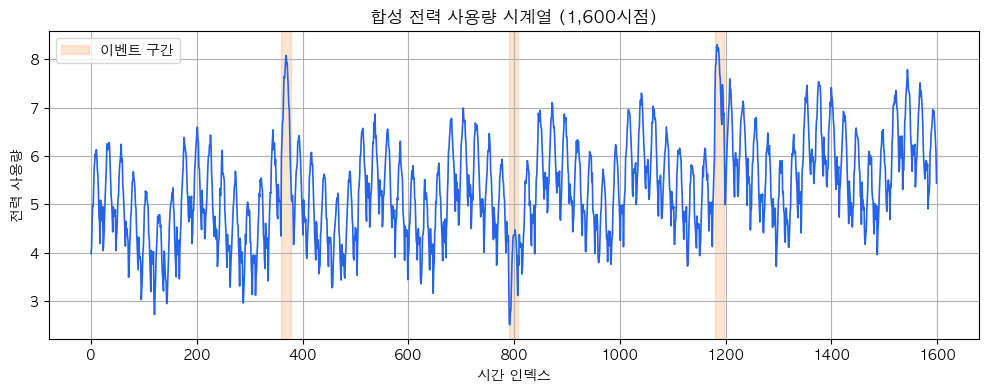

관찰 포인트: 하루 주기, 주간 주기, 추세, 이벤트 피크가 함께 섞인 시계열입니다.
이런 데이터에서는 최근 값만 보는 기준선보다 과거 패턴을 함께 보는 모델이 유리할 수 있습니다.


In [14]:
# [시나리오] 방금 만든 합성 전력 사용량의 추세, 하루 주기, 이벤트 피크를 눈으로 확인합니다.
# 입력: series_df
# 출력: 전력 사용량 시계열 그래프

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series_df["time"], series_df["energy"], color="#2563EB", linewidth=1.2)
ax.set_title("합성 전력 사용량 시계열 (1,600시점)")
ax.set_xlabel("시간 인덱스")
ax.set_ylabel("전력 사용량")
ax.axvspan(360, 378, color="#F97316", alpha=0.18, label="이벤트 구간")
ax.axvspan(790, 808, color="#F97316", alpha=0.18)
ax.axvspan(1180, 1198, color="#F97316", alpha=0.18)
ax.legend(loc="upper left")
plt.show()

print("관찰 포인트: 하루 주기, 주간 주기, 추세, 이벤트 피크가 함께 섞인 시계열입니다.")
print("이런 데이터에서는 최근 값만 보는 기준선보다 과거 패턴을 함께 보는 모델이 유리할 수 있습니다.")


---

## Part 2. Attention의 직관 — Query, Key, Value

Attention은 “현재 예측에 필요한 과거 시점은 어디인가요?”라는 질문을 수치화합니다.

| 구성 | 직관 | 시계열 예시 |
|------|------|-------------|
| Query | 지금 찾고 싶은 정보 | 다음 전력 사용량을 예측하려는 현재 상황 |
| Key | 각 과거 시점의 주소 | 과거 48시간 각각의 패턴 요약 |
| Value | 실제로 가져올 정보 | 과거 시점의 특징 벡터 |

<img src="images/04_transformer_timeseries/qkv_attention.png" width="900">

수식은 다음과 같습니다.

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

아래 그림은 Self-Attention의 실제 계산 순서를 한 장으로 정리한 것입니다. 같은 입력 시계열 `X`에서 `Q`, `K`, `V`를 각각 만들고, `QK^T` 점수와 `softmax` 가중치로 `Value`를 섞어 출력 `Z`를 만듭니다.

<img src="images/04_transformer_timeseries/qkv_self_attention_flow.png" width="1000">

> $QK^T$는 Query와 Key의 유사도입니다. 유사도가 큰 시점의 Value가 더 많이 섞입니다.


In [15]:
# [시나리오] 3개의 과거 시점 중 현재 Query와 가장 비슷한 Key에 attention weight가 커지는지 손계산으로 확인합니다.
# 입력: Query 1개, Key 3개, Value 3개
# 출력: attention weight와 가중합 결과

Q = torch.tensor([[1.0, 0.2]])
K = torch.tensor([
    [0.9, 0.1],   # 현재 Query와 가장 비슷한 과거 시점
    [0.1, 0.8],
    [0.4, 0.4],
])
V = torch.tensor([
    [10.0, 0.0],  # 첫 번째 시점의 실제 정보
    [0.0, 8.0],
    [3.0, 3.0],
])

d_k = K.shape[-1]
scores = Q @ K.T / math.sqrt(d_k)
weights = torch.softmax(scores, dim=-1)
context = weights @ V

print("Attention 점수:", np.round(scores.numpy(), 3))
print("Attention 가중치:", np.round(weights.numpy(), 3))
print("가중합 결과:", np.round(context.numpy(), 3))
print(f"  -> 가장 큰 가중치 위치: {weights.argmax().item() + 1}번째 과거 시점")
print("관찰 포인트: Query와 가장 비슷한 Key가 가장 크게 반영됩니다.")


Attention 점수: [[0.651 0.184 0.339]]
Attention 가중치: [[0.424 0.266 0.31 ]]
가중합 결과: [[5.169 3.057]]
  -> 가장 큰 가중치 위치: 1번째 과거 시점
관찰 포인트: Query와 가장 비슷한 Key가 가장 크게 반영됩니다.


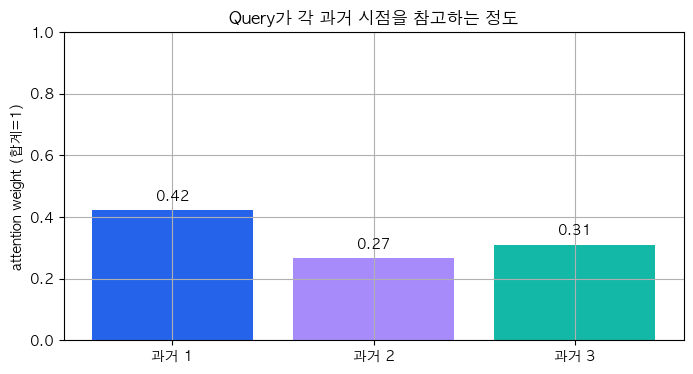

관찰 포인트: attention weight는 확률처럼 합이 1이며, 중요한 시점일수록 더 큰 값을 가집니다.


In [16]:
# [시나리오] 위 손계산 결과를 막대그래프로 시각화하여 어떤 과거 시점이 선택되었는지 확인합니다.
# 입력: attention weights
# 출력: 과거 시점별 attention weight 막대그래프

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["과거 1", "과거 2", "과거 3"]
ax.bar(labels, weights.squeeze().numpy(), color=["#2563EB", "#A78BFA", "#14B8A6"])
ax.set_ylim(0, 1)
ax.set_ylabel("attention weight (합계=1)")
ax.set_title("Query가 각 과거 시점을 참고하는 정도")
for i, v in enumerate(weights.squeeze().numpy()):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontweight="bold")
plt.show()

print("관찰 포인트: attention weight는 확률처럼 합이 1이며, 중요한 시점일수록 더 큰 값을 가집니다.")


---

## Part 3. Self-Attention — 같은 시계열 안에서 서로를 봅니다

Self-Attention은 Query, Key, Value가 모두 같은 입력 $X$에서 나옵니다.

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

Part 2의 흐름 그림처럼 Self-Attention은 먼저 모든 시점의 Q/K/V를 만들고, 모든 시점 쌍의 관계를 점수 행렬로 계산합니다. 이렇게 하면 각 시점은 자기 자신뿐 아니라 같은 시계열의 다른 시점도 직접 참고할 수 있습니다.

<img src="images/04_transformer_timeseries/self_attention_matrix.png" width="760">

> RNN/LSTM은 시점을 순서대로 지나가지만, Self-Attention은 모든 시점 쌍의 관계를 한 번에 계산합니다.


In [ ]:
# [시나리오] 작은 시계열 윈도우에서 Self-Attention 행렬을 직접 계산합니다.
# 입력: 6시점짜리 1차원 시계열
# 출력: 각 시점이 다른 시점을 참고하는 attention matrix

mini_x = torch.tensor([
    [4.0],
    [4.8],
    [5.2],
    [4.6],
    [6.1],
    [6.4],
], dtype=torch.float32)

W_Q = torch.tensor([[0.8, 0.2]], dtype=torch.float32)
W_K = torch.tensor([[0.7, 0.3]], dtype=torch.float32)
W_V = torch.tensor([[1.0, -0.4]], dtype=torch.float32)

Q = mini_x @ W_Q
K = mini_x @ W_K
V = mini_x @ W_V

attn_scores = Q @ K.T / math.sqrt(Q.shape[-1])
attn_weights = torch.softmax(attn_scores, dim=-1)
attn_output = attn_weights @ V

print("Self-Attention 행렬 shape:", tuple(attn_weights.shape))
print("마지막 시점이 참고한 가중치:", np.round(attn_weights[-1].numpy(), 3))
print("마지막 시점의 출력 벡터:", np.round(attn_output[-1].numpy(), 3))
print("관찰 포인트: 행 하나는 특정 시점이 전체 과거 시점을 얼마나 참고하는지 나타냅니다.")

attn_output.shape

In [ ]:
# [시나리오] Self-Attention 행렬을 heatmap으로 그려 각 시점 간 관계를 확인합니다.
# 입력: attn_weights
# 출력: attention matrix heatmap

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(attn_weights.numpy(), cmap="YlGnBu", vmin=0, vmax=attn_weights.max().item())
ax.set_title("작은 시계열의 Self-Attention Matrix")
ax.set_xlabel("참조되는 시점 Key")
ax.set_ylabel("현재 시점 Query")
ax.set_xticks(range(6), [f"t-{5-i}" if i < 5 else "t" for i in range(6)])
ax.set_yticks(range(6), [f"t-{5-i}" if i < 5 else "t" for i in range(6)])
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{attn_weights[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="attention weight (합계=1)")
plt.show()

print("관찰 포인트: Self-Attention에서는 한 시점이 멀리 떨어진 시점도 직접 참고할 수 있습니다.")


---

## Part 4. Positional Encoding — Attention은 순서를 따로 배워야 합니다

Self-Attention은 시점 간 관계를 잘 계산하지만, 그 자체만으로는 “몇 번째 시점인가요?”라는 순서를 알기 어렵습니다. 그래서 Transformer는 입력 벡터에 위치 정보를 더합니다.

<img src="images/04_transformer_timeseries/positional_encoding.png" width="900">

대표적인 sinusoidal positional encoding은 다음과 같이 정의됩니다.

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

> 시계열 예측에서는 같은 값이라도 “최근 1시간 전”인지 “24시간 전”인지가 매우 중요합니다.


In [ ]:
# [시나리오] sinusoidal positional encoding을 만들어 위치마다 서로 다른 벡터가 생기는지 확인합니다.
# 입력: max_len=48, d_model=16
# 출력: 위치 인코딩 행렬과 일부 값

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


pe_demo = PositionalEncoding(d_model=16, max_len=48).pe.squeeze(0)
print("Positional Encoding shape:", tuple(pe_demo.shape))
print("0번 위치 앞 6개 값:", np.round(pe_demo[0, :6].numpy(), 3))
print("1번 위치 앞 6개 값:", np.round(pe_demo[1, :6].numpy(), 3))
print("관찰 포인트: 위치마다 더해지는 벡터가 다르기 때문에 모델이 순서를 구분할 수 있습니다.")


In [ ]:
# [시나리오] 위치 인코딩의 일부 차원을 선 그래프로 확인합니다.
# 입력: pe_demo
# 출력: 위치별 sinusoidal encoding 곡선

fig, ax = plt.subplots(figsize=(10, 4))
for dim in [0, 1, 2, 3]:
    ax.plot(pe_demo[:, dim].numpy(), label=f"dim {dim}")
ax.set_title("Sinusoidal Positional Encoding 일부 차원")
ax.set_xlabel("위치 pos")
ax.set_ylabel("encoding value")
ax.legend()
plt.show()

print("관찰 포인트: 낮은 차원은 빠르게 변하고, 높은 차원은 더 천천히 변하면서 여러 시간 스케일을 제공합니다.")


---

## Part 5. Multi-Head Attention — 여러 관점으로 봅니다

전력 사용량 같은 시계열에는 여러 패턴이 섞여 있습니다.

| 관점 | 예시 |
|------|------|
| 최근 변화 | 마지막 몇 시간의 급격한 증가 |
| 하루 주기 | 24시간 전 같은 시간대 |
| 주간 패턴 | 7일 주기의 반복 |
| 이벤트 | 비정상 피크나 급락 |

Multi-Head Attention은 여러 attention head가 서로 다른 표현 공간에서 관계를 계산하게 합니다.

<img src="images/04_transformer_timeseries/multi_head_attention.png" width="900">


In [ ]:
# [시나리오] PyTorch MultiheadAttention이 입력 시계열을 어떤 shape로 처리하는지 확인합니다.
# 입력: batch=2, seq_len=48, d_model=32 텐서
# 출력: attention 출력과 head별 attention weight shape

set_seed(42)
demo_batch = torch.randn(2, 48, 32)
mha = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=True)
attn_out, attn_w = mha(
    demo_batch,
    demo_batch,
    demo_batch,
    need_weights=True,
    average_attn_weights=False,  # head별 attention weight를 따로 확인합니다.
)

print("입력 shape:", tuple(demo_batch.shape))
print("Multi-Head Attention 출력 shape:", tuple(attn_out.shape))
print("head별 attention weight shape:", tuple(attn_w.shape))
print("  -> 의미: (batch, num_heads, query_len, key_len)")
print("Head 1의 마지막 시점 attention 앞 5개:", np.round(attn_w[0, 0, -1, :5].detach().numpy(), 3))
print("Head 2의 마지막 시점 attention 앞 5개:", np.round(attn_w[0, 1, -1, :5].detach().numpy(), 3))
print("관찰 포인트: Multi-Head Attention은 head별 attention weight를 따로 계산합니다.")
print("관찰 포인트: 출력은 입력과 같은 길이의 시퀀스이며, 각 시점 표현이 다른 시점 정보를 섞어 갱신됩니다.")


---

## Part 6. Transformer Encoder — 시계열에 적용하는 일반 Transformer

이번 교안의 `TimeSeriesTransformer`는 특정 라이브러리의 고유 모델명이 아닙니다. **일반 Transformer Encoder를 시계열 예측용으로 감싼 PyTorch 클래스**입니다.

구성은 다음과 같습니다.

<img src="images/04_transformer_timeseries/transformer_encoder_block.png" width="900">

| 단계 | 역할 |
|------|------|
| 입력 투영 | 1차원 전력 사용량을 `d_model` 차원 벡터로 변환 |
| Positional Encoding | 시점 순서 정보를 입력 표현에 추가 |
| Transformer Encoder | Multi-Head Self-Attention + FFN으로 시점 관계 학습 |
| Add & LayerNorm | 잔차 연결 후 표현 스케일을 안정적으로 유지 |
| 예측 Head | 마지막 시점 표현으로 다음 1시점 사용량 예측 |


### LayerNorm은 왜 필요할까요?

Transformer Encoder 안에서는 Self-Attention 출력과 FFN 출력이 잔차 연결(residual connection)로 계속 더해집니다. 이때 표현의 스케일이 계속 커지거나 특정 차원에 치우치면 학습이 불안정해질 수 있습니다.

LayerNorm은 각 샘플의 각 시점마다 **특징 차원(`d_model`) 내부**에서 평균과 표준편차를 계산해 표현의 스케일을 맞춥니다.

Transformer의 중간 텐서가 보통 `(batch, seq_len, d_model)` 형태라면, LayerNorm은 아래처럼 마지막 차원만 정규화합니다.

```python
x[b, t, :]  # 하나의 샘플 b, 하나의 시점/토큰 t에 있는 d_model개 특징
```

즉, **batch 방향끼리 평균을 내지 않습니다.** 또한 **여러 시점(`seq_len`)을 섞어서 평균을 내지도 않습니다.** 각 토큰 벡터 하나 안의 `d_model`개 값만 보고 평균과 표준편차를 계산합니다.

<img src="images/04_transformer_timeseries/layernorm_principle.png" width="950">

다른 normalization과 비교하면 LayerNorm의 방향이 더 분명해집니다. 아래 그림에서 색 영역은 평균과 분산을 함께 계산하는 단위입니다.

<img src="images/04_transformer_timeseries/normalization_axis_comparison.png" width="1000">

수식은 다음과 같습니다.

$$
\text{LayerNorm}(x_{b,t,:}) = \gamma \frac{x_{b,t,:} - \mu_{b,t}}{\sqrt{\sigma_{b,t}^2 + \epsilon}} + \beta
$$

여기서 $\mu_{b,t}$와 $\sigma_{b,t}$는 한 토큰 `x[b, t, :]`의 특징 차원 안에서 계산한 평균과 표준편차입니다. $\gamma$와 $\beta$는 모델이 학습하는 스케일과 이동 파라미터입니다.

> BatchNorm은 보통 batch 통계를 사용하지만, LayerNorm은 각 샘플의 각 토큰 내부에서 계산되므로 batch 크기가 작거나 시퀀스 길이가 달라도 안정적으로 사용할 수 있습니다.


In [ ]:
# [시나리오] LayerNorm이 각 시점의 특징 차원을 평균 0, 표준편차 1에 가깝게 맞추는지 확인합니다.
# 입력: (batch=1, seq_len=3, d_model=4) 예시 텐서
# 출력: LayerNorm 전후의 시점별 평균과 표준편차

layernorm_input = torch.tensor([[
    [3.0, 6.0, 7.5, 10.0],
    [1.0, 2.5, 8.0, 12.0],
    [4.0, 4.5, 5.0, 7.0],
]], dtype=torch.float32)

ln = nn.LayerNorm(normalized_shape=4, elementwise_affine=False)
layernorm_output = ln(layernorm_input)

# dim=-1은 마지막 차원인 d_model 방향입니다.
# 즉 x[b, t, :] 하나의 토큰 벡터 안에서 평균과 표준편차를 계산합니다.
before_mean = layernorm_input.mean(dim=-1)
before_std = layernorm_input.std(dim=-1, unbiased=False)
after_mean = layernorm_output.mean(dim=-1)
after_std = layernorm_output.std(dim=-1, unbiased=False)

print("LayerNorm 입력 shape:", tuple(layernorm_input.shape))
print("정규화 방향: 마지막 차원 d_model=4, 즉 x[b, t, :] 내부입니다.")
print("정규화 전 시점별 평균:", np.round(before_mean.numpy(), 3))
print("정규화 전 시점별 표준편차:", np.round(before_std.numpy(), 3))
print("정규화 후 시점별 평균:", np.round(after_mean.detach().numpy(), 3))
print("정규화 후 시점별 표준편차:", np.round(after_std.detach().numpy(), 3))
print("관찰 포인트: LayerNorm은 batch 방향이나 seq_len 방향이 아니라 각 토큰의 d_model 방향을 정규화합니다.")
print("관찰 포인트: 그래서 Transformer의 Add & Norm 단계에서 표현 스케일을 안정적으로 유지할 수 있습니다.")


In [ ]:
# [시나리오] 일반 Transformer Encoder를 시계열 회귀용 모델 클래스로 정의합니다.
# 입력: (batch, 48, 1) 형태의 과거 전력 사용량
# 출력: (batch, 1) 형태의 다음 시점 예측값

class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        input_dim=1,
        d_model=32,
        nhead=4,
        num_layers=1,
        dim_feedforward=32*4,
        dropout=0.0,
        use_positional_encoding=True,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=256)
        self.use_positional_encoding = use_positional_encoding

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        z = self.input_proj(x)
        if self.use_positional_encoding:
            z = self.pos_encoder(z)
        z = self.encoder(z)
        last_token = z[:, -1, :]
        return self.head(last_token)


model_demo = TimeSeriesTransformer(use_positional_encoding=True)
dummy_x = torch.randn(4, 48, 1)
dummy_pred = model_demo(dummy_x)

print(model_demo)
print("입력 shape:", tuple(dummy_x.shape))
print("출력 shape:", tuple(dummy_pred.shape))
print("관찰 포인트: 일반 Transformer Encoder를 쓰되, 앞뒤에 시계열용 입력 투영과 회귀 head를 붙였습니다.")


---

## Part 7. 종합 실습 — 전력 사용량 다음 값 예측

이제 앞에서 만든 합성 전력 사용량 데이터로 다음 1시점 값을 예측합니다.

정확한 데이터셋 명세는 다음과 같습니다.

| 항목 | 값 |
|------|------|
| 생성 함수 | `make_synthetic_energy_series(n_steps=1600, seed=42)` |
| 원시 길이 | 1,600시점 |
| 입력 윈도우 | 과거 48시점 |
| 예측 목표 | 다음 1시점 사용량 |
| 전체 샘플 수 | 1,552개 |
| 입력 형태 | `X_all.shape = (1552, 48, 1)` |
| 타깃 형태 | `y_all.shape = (1552, 1)` |
| 분할 | train 1,086개, val 232개, test 234개 |

> 중요한 점은 시간 순서를 지키는 것입니다. 미래 정보 누수는 **시간 순 분할**과 **학습셋 기준 표준화**로 막습니다. 여기서는 학습 흐름을 눈으로 따라가기 쉽게 `DataLoader`도 `shuffle=False`로 둡니다.


In [ ]:
# [시나리오] 시계열 데이터를 시간 순서대로 train/val/test로 나누고, 학습셋 기준으로 표준화합니다.
# 입력: X_all, y_all
# 출력: X_tr/y_tr, X_val/y_val, X_te/y_te 및 DataLoader

n_total = len(X_all)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

X_tr, y_tr = X_all[:n_train], y_all[:n_train]
X_val, y_val = X_all[n_train : n_train + n_val], y_all[n_train : n_train + n_val]
X_te, y_te = X_all[n_train + n_val :], y_all[n_train + n_val :]

# 데이터 누수 방지: 평균과 표준편차는 학습셋에서만 계산합니다.
train_mean = X_tr.mean()
train_std = X_tr.std()

X_tr_s = (X_tr - train_mean) / train_std
X_val_s = (X_val - train_mean) / train_std
X_te_s = (X_te - train_mean) / train_std
y_tr_s = (y_tr - train_mean) / train_std
y_val_s = (y_val - train_mean) / train_std

# 학습 구간 안의 batch shuffle 자체가 미래 정보 누수는 아닙니다.
# 여기서는 시계열 흐름을 설명하기 쉽도록 shuffle=False를 사용합니다.
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_s), torch.tensor(y_tr_s)),
    batch_size=64,
    shuffle=False,
)

print(f"train: {X_tr.shape}, {y_tr.shape}")
print(f"val:   {X_val.shape}, {y_val.shape}")
print(f"test:  {X_te.shape}, {y_te.shape}")
print(f"학습셋 평균: {train_mean:.3f}, 학습셋 표준편차: {train_std:.3f}")
print("관찰 포인트: 미래 정보 누수는 시간 순 분할과 학습셋 기준 표준화로 막습니다.")
print("관찰 포인트: shuffle=False는 이번 교안에서 시간 흐름을 설명하기 위한 선택입니다.")


In [ ]:
# [시나리오] 위치 인코딩 ON/OFF Transformer와 naive baseline을 비교하기 위한 학습 함수를 정의합니다.
# 입력: use_positional_encoding 옵션
# 출력: 검증 손실 기록, 테스트 예측값, 테스트 MAE

def train_transformer(use_positional_encoding=True, seed=42, epochs=22):
    set_seed(seed)
    model = TimeSeriesTransformer(
        d_model=32,
        nhead=4,
        num_layers=1,
        dim_feedforward=64,
        dropout=0.0,
        use_positional_encoding=use_positional_encoding,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=0.001)
    loss_fn = nn.SmoothL1Loss()

    X_val_t = torch.tensor(X_val_s)
    y_val_t = torch.tensor(y_val_s)
    X_te_t = torch.tensor(X_te_s)

    best_state = None
    best_val = float("inf")
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()
        history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_loss": val_loss})

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_s = model(X_te_t).numpy()

    pred = pred_s * train_std + train_mean
    mae = float(np.mean(np.abs(pred - y_te)))
    return model, pd.DataFrame(history), pred, mae


naive_pred = X_te[:, -1, 0:1]
naive_mae = float(np.mean(np.abs(naive_pred - y_te)))

print(f"Naive baseline MAE: {naive_mae:.4f}")
print("관찰 포인트: naive baseline은 '다음 값은 마지막 값과 같을 것'이라고 예측하는 단순 기준선입니다.")


In [ ]:
# [시나리오] 같은 데이터에서 위치 인코딩 ON/OFF Transformer를 학습해 실제 차이를 확인합니다.
# 입력: train_transformer 함수, train/val/test 데이터
# 출력: 위치 인코딩 ON/OFF의 테스트 MAE 비교

model_pe, hist_pe, pred_pe, mae_pe = train_transformer(use_positional_encoding=True, seed=42, epochs=22)
model_no_pe, hist_no_pe, pred_no_pe, mae_no_pe = train_transformer(use_positional_encoding=False, seed=42, epochs=22)

improve_vs_naive = (naive_mae - mae_pe) / naive_mae * 100
improve_vs_no_pe = (mae_no_pe - mae_pe) / mae_no_pe * 100

print("테스트 MAE 비교")
print(f"  Naive baseline:           {naive_mae:.4f}")
print(f"  Transformer + 위치 인코딩: {mae_pe:.4f}")
print(f"  Transformer - 위치 인코딩: {mae_no_pe:.4f}")
print(f"  -> Naive 대비 개선율: {improve_vs_naive:.1f}%")
print(f"  -> 위치 인코딩 OFF 대비 개선율: {improve_vs_no_pe:.1f}%")
print("관찰 포인트: 같은 Transformer 구조라도 위치 정보가 없으면 시계열의 순서를 충분히 활용하기 어렵습니다.")


In [ ]:
# [시나리오] 학습 곡선과 테스트 구간 예측 결과를 함께 시각화합니다.
# 입력: hist_pe, hist_no_pe, pred_pe, pred_no_pe, naive_pred, y_te
# 출력: 손실 곡선과 테스트 예측 그래프

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_pe["epoch"], hist_pe["val_loss"], label="PE ON", color="#059669", linewidth=2)
axes[0].plot(hist_no_pe["epoch"], hist_no_pe["val_loss"], label="PE OFF", color="#E11D48", linewidth=2)
axes[0].set_title("검증 손실 곡선")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("SmoothL1 loss")
axes[0].legend()

view_n = 140
axes[1].plot(y_te[:view_n], label="실제값", color="#111827", linewidth=2)
axes[1].plot(pred_pe[:view_n], label="Transformer PE ON", color="#059669", linewidth=1.6)
axes[1].plot(pred_no_pe[:view_n], label="Transformer PE OFF", color="#E11D48", linewidth=1.2, alpha=0.8)
axes[1].plot(naive_pred[:view_n], label="Naive", color="#6B7280", linewidth=1.1, alpha=0.7)
axes[1].set_title("테스트 구간 예측 비교")
axes[1].set_xlabel("테스트 시점")
axes[1].set_ylabel("전력 사용량")
axes[1].legend()

plt.tight_layout()
plt.show()

print("관찰 포인트: 위치 인코딩을 켠 Transformer가 실제 곡선을 더 가깝게 따라갑니다.")
print("이 결과는 Phase 2.5 사전 실험에서 먼저 확인한 뒤 본문에 반영한 값입니다.")


In [ ]:
# [시나리오] 테스트 MAE를 표로 정리하여 최종 판단을 내립니다.
# 입력: naive_mae, mae_pe, mae_no_pe
# 출력: 모델별 MAE와 개선율 표

result_df = pd.DataFrame({
    "모델": ["Naive baseline", "Transformer + 위치 인코딩", "Transformer - 위치 인코딩"],
    "Test MAE": [naive_mae, mae_pe, mae_no_pe],
})
result_df["Naive 대비 개선율(%)"] = (naive_mae - result_df["Test MAE"]) / naive_mae * 100

display(result_df)

best_model = result_df.loc[result_df["Test MAE"].idxmin(), "모델"]
print(f"최종 판단: 이 실험에서는 '{best_model}'이 가장 낮은 테스트 MAE를 보입니다.")
print("관찰 포인트: Transformer의 강점은 attention 구조뿐 아니라, 위치 정보를 함께 넣었을 때 시계열 순서를 활용한다는 점입니다.")


---

## 핵심 정리

### 개념 한눈에 보기

| 주제 | 핵심 |
|------|------|
| RNN/LSTM 병목 | 긴 시계열을 마지막 hidden 하나에 압축하는 부담이 있습니다 |
| Attention | Query와 Key의 유사도로 중요한 Value를 더 많이 섞습니다 |
| Self-Attention | 같은 시계열 내부 시점들이 서로를 직접 참고합니다 |
| Positional Encoding | Attention에 시간 순서 정보를 추가합니다 |
| Multi-Head Attention | 여러 head가 단기 변화, 주기, 이벤트를 다른 관점으로 볼 수 있습니다 |
| Transformer Encoder | 입력 투영 + 위치 인코딩 + Self-Attention + FFN + Add & LayerNorm 구조입니다 |
| LayerNorm | 각 시점의 특징 차원 내부를 정규화해 표현 스케일을 안정화합니다 |
| 시계열 예측 주의점 | 시간 순 분할과 학습셋 기준 표준화로 미래 정보 누수를 막아야 합니다 |

### 핵심 코드

| 코드 | 역할 |
|------|------|
| `Q = X @ W_Q` | Query 생성 |
| `K = X @ W_K` | Key 생성 |
| `V = X @ W_V` | Value 생성 |
| `torch.softmax(Q @ K.T / sqrt(d_k), dim=-1)` | attention weight 계산 |
| `nn.MultiheadAttention(..., batch_first=True)` | PyTorch Multi-Head Attention |
| `nn.TransformerEncoderLayer(..., batch_first=True)` | Transformer Encoder 기본 블록 |
| `nn.LayerNorm(d_model)` | 특징 차원 기준 LayerNorm |
| `z[:, -1, :]` | 마지막 시점 표현으로 many-to-one 예측 |
| `torch.optim.AdamW(...)` | Transformer 학습에 사용한 optimizer |

### 다음 시간 예고

이번 챕터에서는 일반 Transformer Encoder로 수치형 시계열의 다음 값을 예측했습니다. 다음에는 다음 방향으로 확장할 수 있습니다.

| 주제 | 한 줄 |
|------|------|
| Encoder-Decoder Transformer | 입력 시퀀스에서 출력 시퀀스 전체를 생성합니다 |
| Causal Mask | 미래 시점을 보지 못하게 막아 자기회귀 예측을 만듭니다 |
| Patch 기반 시계열 Transformer | 긴 시계열을 작은 구간 단위로 나누어 효율적으로 처리합니다 |
| CNN/Transformer 비교 | 지역 패턴과 장기 의존성을 어떤 구조가 잘 잡는지 비교합니다 |

> 다음 챕터에서 만나요!
